## Uppgift 12

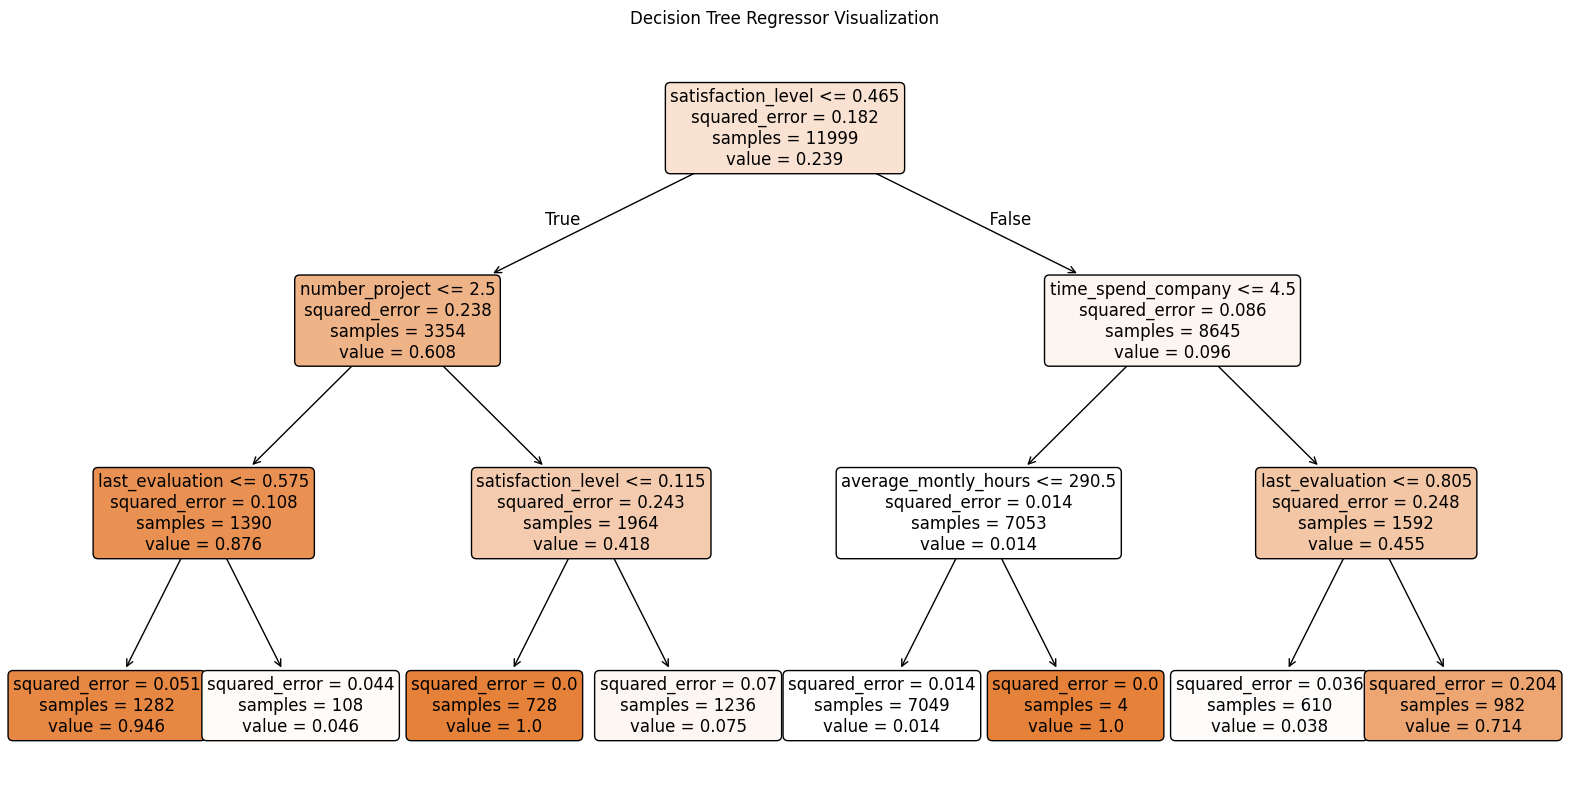

In [2]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X.columns, filled=True, rounded=True, fontsize=12)
plt.title("Decision Tree Regressor Visualization")
plt.show()

## Uppgift 13

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_excel('hr_employee_data.xlsx')

# remake text to numbers
df_final = pd.get_dummies(df, drop_first=True)

# difine X och y
X = df_final.drop('left', axis=1)
y = df_final['left']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# rewaluate the model
y_pred = model.predict(X_test)

print(f"Model's Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Model's Accuracy: 0.97

Detailed Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2294
           1       0.98      0.91      0.94       706

    accuracy                           0.97      3000
   macro avg       0.98      0.95      0.96      3000
weighted avg       0.98      0.97      0.97      3000



## Uppgift 14

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from IPython.display import Image

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
iris = load_iris()
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [6]:
X, y = load_iris(return_X_y=True, as_frame=True)
X = X[['sepal length (cm)', 'sepal width (cm)']]

print(X.info())
print(y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 150 entries, 0 to 149
Series name: target
Non-Null Count  Dtype
--------------  -----
150 non-null    int64
dtypes: int64(1)
memory usage: 1.3 KB
None


In [7]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)

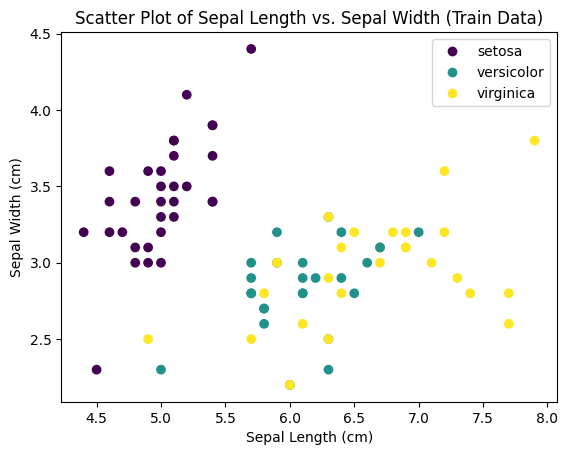

In [8]:
classes = ['setosa', 'versicolor', 'virginica']
scatter = plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width (Train Data)')
plt.legend(handles=scatter.legend_elements()[0], labels=classes)

In [12]:
X_train.head()

,sepal length (cm),sepal width (cm)
72,6.3,2.5
62,6.0,2.2
74,6.4,2.9
19,5.1,3.8
93,5.0,2.3


In [13]:
y_train.head()

72    1
62    1
74    1
19    0
93    1
Name: target, dtype: int64

In [14]:
y_train.value_counts()

target
0    32
1    26
2    26
Name: count, dtype: int64

In [15]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_val)

In [16]:
tree_clf = DecisionTreeClassifier()

hyper_params = {'max_depth':(None, 1, 2, 5, 10)}
clf = GridSearchCV(tree_clf, hyper_params)

clf.fit(X_train, y_train)
clf_pred = clf.predict(X_val)

In [17]:
print(clf.best_params_)
pd.DataFrame(clf.cv_results_)

{'max_depth': 2}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005599,0.005069,0.003277,0.001196,None,{'max_depth': None},0.588235,0.647059,0.764706,0.764706,0.6250,0.677941,0.073294,3
1,0.002578,0.000250,0.002445,0.000542,1,{'max_depth': 1},0.647059,0.705882,0.705882,0.647059,0.5625,0.653676,0.052634,5
2,0.002574,0.000265,0.002018,0.000187,2,{'max_depth': 2},0.764706,0.647059,0.823529,0.882353,0.6250,0.748529,0.099349,1
3,0.002665,0.000561,0.002048,0.000410,5,{'max_depth': 5},0.705882,0.647059,0.823529,0.823529,0.5625,0.712500,0.101471,2
4,0.002572,0.000318,0.002107,0.000338,10,{'max_depth': 10},0.529412,0.647059,0.764706,0.764706,0.6250,0.666176,0.089646,4


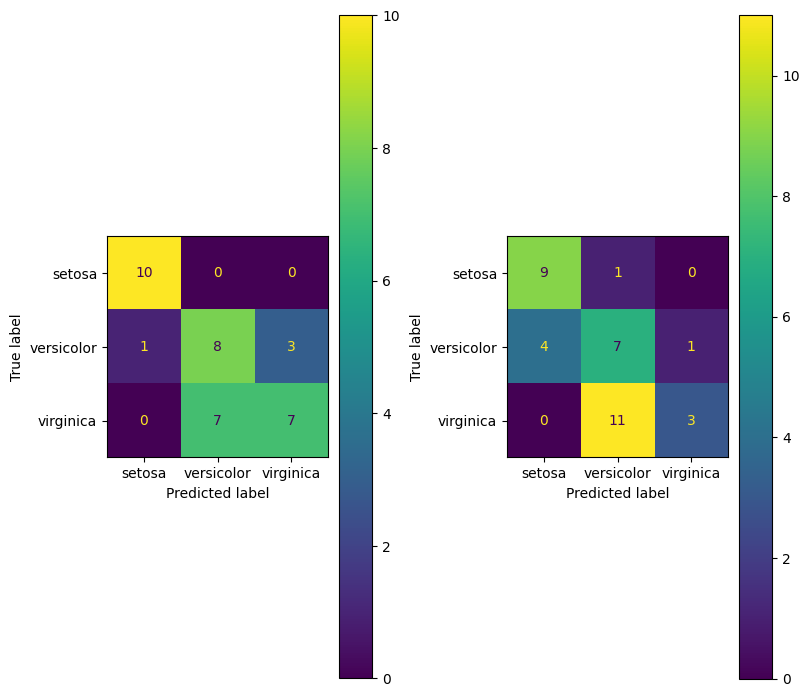

In [18]:
target_names_iris = ['setosa', 'versicolor', 'virginica']

cm1 = confusion_matrix(y_val, log_reg_pred)
cm2 = confusion_matrix(y_val, clf_pred)

fig, axs = plt.subplots(1, 2, figsize = (8, 7), layout='constrained')
ConfusionMatrixDisplay(cm1, display_labels = target_names_iris).plot(ax=axs[0])
ConfusionMatrixDisplay(cm2, display_labels = target_names_iris).plot(ax=axs[1])

In [20]:
print(classification_report(y_val, log_reg_pred, target_names=target_names_iris))
print(classification_report(y_val, clf_pred, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.53      0.67      0.59        12
   virginica       0.70      0.50      0.58        14

    accuracy                           0.69        36
   macro avg       0.71      0.72      0.71        36
weighted avg       0.70      0.69      0.69        36

              precision    recall  f1-score   support

      setosa       0.69      0.90      0.78        10
  versicolor       0.37      0.58      0.45        12
   virginica       0.75      0.21      0.33        14

    accuracy                           0.53        36
   macro avg       0.60      0.57      0.52        36
weighted avg       0.61      0.53      0.50        36



In [21]:
log_reg_final = LogisticRegression().fit(X_train_full, y_train_full)
pred_test = log_reg_final.predict(X_test)

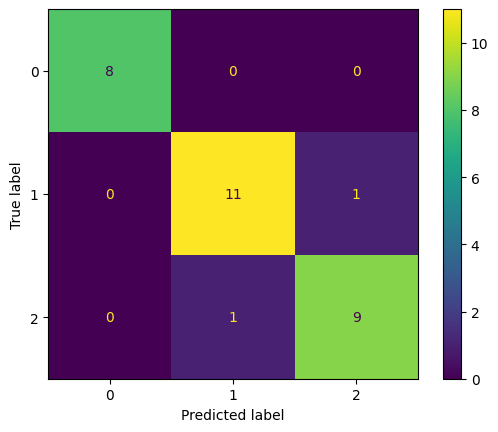

In [22]:
cm_test = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm_test).plot()

In [23]:
print(classification_report(y_test, pred_test, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.92      0.92      0.92        12
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30

